<a href="https://colab.research.google.com/github/GabrielaRguezCampos/other/blob/main/DeepLearning_Milestone4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 4: Baseline Model for Multi-Task Sentiment Analysis

**Project:** Multi-Task Sentiment Analysis for Product Reviews Using Deep Learning

**Team Members:**
- Carlos Hernandez
- Gabriela Rodriguez
- Sara Salvatierra

## Overview
This notebook implements our baseline model using a Bi-directional LSTM for sentiment analysis and rating prediction on Yelp reviews.

## 1. Environment Setup and Imports

In [ ]:
# Install required packages
!pip install -q datasets transformers torch torchvision torchaudio
!pip install -q scikit-learn matplotlib seaborn

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
import re
from tqdm import tqdm

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Dataset Loading and Exploration

In [ ]:
# Load Yelp dataset
print("Loading Yelp Review dataset...")
dataset = load_dataset("Yelp/yelp_review_full", split="train[:50000]")
df = pd.DataFrame(dataset)

# Map labels 0-4 to ratings 1-5
df['rating'] = df['label'] + 1

# Create sentiment labels (negative: 1-2, neutral: 3, positive: 4-5)
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading Yelp Review dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset shape: (50000, 4)
Columns: ['label', 'text', 'rating', 'sentiment']


In [ ]:
# Dataset statistics
print("\n=== Dataset Statistics ===")
print("\nRating Distribution (1-5 stars):")
print(df['rating'].value_counts().sort_index())

print("\nSentiment Distribution:")
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
sentiment_counts = df['sentiment'].value_counts().sort_index()
for sent_id, count in sentiment_counts.items():
    print(f"{sentiment_map[sent_id]}: {count} ({count/len(df)*100:.1f}%)")

# Text length analysis
df['text_length'] = df['text'].str.len()
print(f"\nText Length Statistics:")
print(f"Mean: {df['text_length'].mean():.0f} chars")
print(f"Median: {df['text_length'].median():.0f} chars")
print(f"Min/Max: {df['text_length'].min()}/{df['text_length'].max()} chars")


=== Dataset Statistics ===

Rating Distribution (1-5 stars):
rating
1    10875
2    10277
3     9875
4     9802
5     9171
Name: count, dtype: int64

Sentiment Distribution:
Negative: 21152 (42.3%)
Neutral: 9875 (19.8%)
Positive: 18973 (37.9%)

Text Length Statistics:
Mean: 698 chars
Median: 518 chars
Min/Max: 1/5068 chars


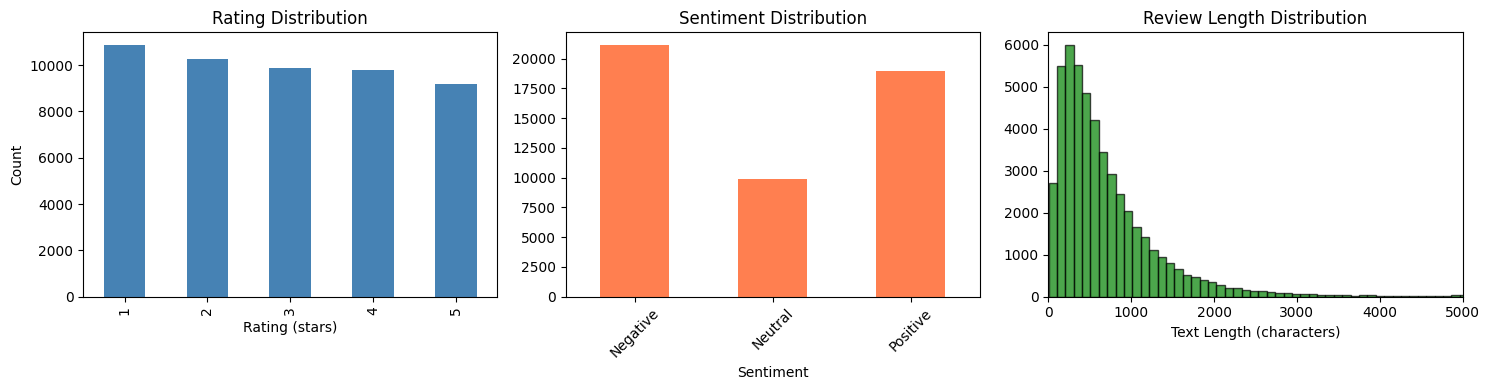

In [ ]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Count')

# Sentiment distribution
sentiment_labels = ['Negative', 'Neutral', 'Positive']
df['sentiment'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Sentiment Distribution')
axes[1].set_xticklabels(sentiment_labels, rotation=45)
axes[1].set_xlabel('Sentiment')

# Text length distribution
axes[2].hist(df['text_length'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].set_title('Review Length Distribution')
axes[2].set_xlabel('Text Length (characters)')
axes[2].set_xlim(0, 5000)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [ ]:
# # Text preprocessing function
# def preprocess_text(text):
#     """Basic text preprocessing"""
#     # Convert to lowercase
#     text = text.lower()
#     # Remove extra whitespace
#     text = ' '.join(text.split())
#     # Keep only alphanumeric and basic punctuation
#     text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?]', '', text)
#     return text

# # Apply preprocessing
# print("Preprocessing text...")
# df['processed_text'] = df['text'].apply(preprocess_text)

# # Show example
# print("\nOriginal text sample:")
# print(df['text'].iloc[0][:200])
# print("\nProcessed text sample:")
# print(df['processed_text'].iloc[0][:200])

In [ ]:
# # Build vocabulary
# class Vocabulary:
#     def __init__(self, max_vocab_size=10000):
#         self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}
#         self.idx2word = {0: '<PAD>', 1: '<UNK>', 2: '<SOS>', 3: '<EOS>'}
#         self.word_count = Counter()
#         self.max_vocab_size = max_vocab_size

#     def build_vocabulary(self, texts):
#         # Count words
#         for text in texts:
#             words = text.split()
#             self.word_count.update(words)

#         # Get most common words
#         most_common = self.word_count.most_common(self.max_vocab_size - len(self.word2idx))

#         # Add to vocabulary
#         for word, _ in most_common:
#             idx = len(self.word2idx)
#             self.word2idx[word] = idx
#             self.idx2word[idx] = word

#     def text_to_sequence(self, text, max_length=300):
#         words = text.split()
#         sequence = [self.word2idx.get(word, 1) for word in words[:max_length]]  # 1 is <UNK>
#         return sequence

#     def __len__(self):
#         return len(self.word2idx)

# # Create vocabulary
# print("Building vocabulary...")
# vocab = Vocabulary(max_vocab_size=10000)
# vocab.build_vocabulary(df['processed_text'].values)
# print(f"Vocabulary size: {len(vocab)}")

# # Show most common words
# print("\nMost common words:")
# for word, count in vocab.word_count.most_common(10):
#     print(f"  {word}: {count}")

In [ ]:
# # Convert texts to sequences
# MAX_LENGTH = 300  # Truncate/pad to this length

# print("Converting texts to sequences...")
# sequences = [vocab.text_to_sequence(text, MAX_LENGTH) for text in df['processed_text'].values]

# # Pad sequences
# def pad_sequences(sequences, max_length):
#     padded = []
#     for seq in sequences:
#         if len(seq) < max_length:
#             padded.append(seq + [0] * (max_length - len(seq)))
#         else:
#             padded.append(seq[:max_length])
#     return np.array(padded)

# X = pad_sequences(sequences, MAX_LENGTH)
# y_rating = df['label'].values  # 0-4 for 1-5 stars
# y_sentiment = df['sentiment'].values  # 0: neg, 1: neutral, 2: pos

# print(f"\nInput shape: {X.shape}")
# print(f"Rating labels shape: {y_rating.shape}")
# print(f"Sentiment labels shape: {y_sentiment.shape}")

In [ ]:
# # Split data into train, validation, and test sets
# X_temp, X_test, y_rating_temp, y_rating_test, y_sentiment_temp, y_sentiment_test = train_test_split(
#     X, y_rating, y_sentiment, test_size=0.15, random_state=42, stratify=y_rating
# )

# X_train, X_val, y_rating_train, y_rating_val, y_sentiment_train, y_sentiment_val = train_test_split(
#     X_temp, y_rating_temp, y_sentiment_temp, test_size=0.15, random_state=42, stratify=y_rating_temp
# )

# print("Data split:")
# print(f"Train: {X_train.shape[0]} samples")
# print(f"Validation: {X_val.shape[0]} samples")
# print(f"Test: {X_test.shape[0]} samples")

## 4. Baseline Model Architecture

In [ ]:
# class BiLSTMBaseline(nn.Module):
#     """Baseline Bi-LSTM model for multi-task learning"""

#     def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128,
#                  num_layers=2, dropout=0.3):
#         super(BiLSTMBaseline, self).__init__()

#         # Embedding layer
#         self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

#         # Bi-LSTM layers
#         self.lstm = nn.LSTM(
#             embedding_dim,
#             hidden_dim,
#             num_layers=num_layers,
#             batch_first=True,
#             bidirectional=True,
#             dropout=dropout if num_layers > 1 else 0
#         )

#         # Dropout
#         self.dropout = nn.Dropout(dropout)

#         # Task-specific heads
#         # Rating prediction (5 classes: 1-5 stars)
#         self.rating_head = nn.Sequential(
#             nn.Linear(hidden_dim * 2, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, 5)
#         )

#         # Sentiment classification (3 classes: neg, neutral, pos)
#         self.sentiment_head = nn.Sequential(
#             nn.Linear(hidden_dim * 2, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(64, 3)
#         )

#     def forward(self, x):
#         # Embedding
#         embedded = self.embedding(x)
#         embedded = self.dropout(embedded)

#         # LSTM
#         lstm_out, (hidden, cell) = self.lstm(embedded)

#         # Use the last hidden state from both directions
#         # Shape: (batch_size, hidden_dim * 2)
#         last_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)

#         # Apply dropout
#         last_hidden = self.dropout(last_hidden)

#         # Task predictions
#         rating_logits = self.rating_head(last_hidden)
#         sentiment_logits = self.sentiment_head(last_hidden)

#         return rating_logits, sentiment_logits

# # Initialize model
# model = BiLSTMBaseline(
#     vocab_size=len(vocab),
#     embedding_dim=128,
#     hidden_dim=128,
#     num_layers=2,
#     dropout=0.3
# ).to(device)

# print("Model architecture:")
# print(model)
# print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

## 5. Training Setup

In [ ]:
# # Create DataLoaders
# BATCH_SIZE = 64

# # Convert to tensors
# train_dataset = TensorDataset(
#     torch.LongTensor(X_train),
#     torch.LongTensor(y_rating_train),
#     torch.LongTensor(y_sentiment_train)
# )

# val_dataset = TensorDataset(
#     torch.LongTensor(X_val),
#     torch.LongTensor(y_rating_val),
#     torch.LongTensor(y_sentiment_val)
# )

# test_dataset = TensorDataset(
#     torch.LongTensor(X_test),
#     torch.LongTensor(y_rating_test),
#     torch.LongTensor(y_sentiment_test)
# )

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

In [ ]:
# criterion_rating = nn.CrossEntropyLoss()
# criterion_sentiment = nn.CrossEntropyLoss()

# # Multi-task loss weights
# RATING_WEIGHT = 0.6
# SENTIMENT_WEIGHT = 0.4

# # Optimizer
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Learning rate scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', patience=2, factor=0.5
# )

# print("Training setup complete")
# print(f"Loss weights - Rating: {RATING_WEIGHT}, Sentiment: {SENTIMENT_WEIGHT}")

## 6. Training Loop

In [ ]:
# def train_epoch(model, loader, optimizer):
#     """Train for one epoch"""
#     model.train()
#     total_loss = 0
#     rating_correct = 0
#     sentiment_correct = 0
#     total_samples = 0

#     for batch_idx, (inputs, ratings, sentiments) in enumerate(loader):
#         inputs = inputs.to(device)
#         ratings = ratings.to(device)
#         sentiments = sentiments.to(device)

#         # Forward pass
#         rating_logits, sentiment_logits = model(inputs)

#         # Calculate losses
#         loss_rating = criterion_rating(rating_logits, ratings)
#         loss_sentiment = criterion_sentiment(sentiment_logits, sentiments)

#         # Combined loss
#         loss = RATING_WEIGHT * loss_rating + SENTIMENT_WEIGHT * loss_sentiment

#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
#         optimizer.step()

#         # Calculate accuracy
#         _, rating_preds = torch.max(rating_logits, 1)
#         _, sentiment_preds = torch.max(sentiment_logits, 1)

#         rating_correct += (rating_preds == ratings).sum().item()
#         sentiment_correct += (sentiment_preds == sentiments).sum().item()
#         total_samples += inputs.size(0)
#         total_loss += loss.item()

#     avg_loss = total_loss / len(loader)
#     rating_acc = rating_correct / total_samples
#     sentiment_acc = sentiment_correct / total_samples

#     return avg_loss, rating_acc, sentiment_acc


# def evaluate(model, loader):
#     """Evaluate the model"""
#     model.eval()
#     total_loss = 0
#     rating_correct = 0
#     sentiment_correct = 0
#     total_samples = 0

#     all_rating_preds = []
#     all_rating_labels = []
#     all_sentiment_preds = []
#     all_sentiment_labels = []

#     with torch.no_grad():
#         for inputs, ratings, sentiments in loader:
#             inputs = inputs.to(device)
#             ratings = ratings.to(device)
#             sentiments = sentiments.to(device)

#             # Forward pass
#             rating_logits, sentiment_logits = model(inputs)

#             # Calculate losses
#             loss_rating = criterion_rating(rating_logits, ratings)
#             loss_sentiment = criterion_sentiment(sentiment_logits, sentiments)
#             loss = RATING_WEIGHT * loss_rating + SENTIMENT_WEIGHT * loss_sentiment

#             # Predictions
#             _, rating_preds = torch.max(rating_logits, 1)
#             _, sentiment_preds = torch.max(sentiment_logits, 1)

#             # Store predictions for detailed analysis
#             all_rating_preds.extend(rating_preds.cpu().numpy())
#             all_rating_labels.extend(ratings.cpu().numpy())
#             all_sentiment_preds.extend(sentiment_preds.cpu().numpy())
#             all_sentiment_labels.extend(sentiments.cpu().numpy())

#             rating_correct += (rating_preds == ratings).sum().item()
#             sentiment_correct += (sentiment_preds == sentiments).sum().item()
#             total_samples += inputs.size(0)
#             total_loss += loss.item()

#     avg_loss = total_loss / len(loader)
#     rating_acc = rating_correct / total_samples
#     sentiment_acc = sentiment_correct / total_samples

#     return avg_loss, rating_acc, sentiment_acc, (all_rating_preds, all_rating_labels,
#                                                   all_sentiment_preds, all_sentiment_labels)

In [ ]:
# # Training loop
# NUM_EPOCHS = 15
# best_val_loss = float('inf')

# # Track metrics
# train_losses = []
# val_losses = []
# train_rating_accs = []
# val_rating_accs = []
# train_sentiment_accs = []
# val_sentiment_accs = []

# print("Starting training...")
# print("=" * 60)

# for epoch in range(NUM_EPOCHS):
#     # Train
#     train_loss, train_rating_acc, train_sentiment_acc = train_epoch(model, train_loader, optimizer)

#     # Validate
#     val_loss, val_rating_acc, val_sentiment_acc, _ = evaluate(model, val_loader)

#     # Store metrics
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_rating_accs.append(train_rating_acc)
#     val_rating_accs.append(val_rating_acc)
#     train_sentiment_accs.append(train_sentiment_acc)
#     val_sentiment_accs.append(val_sentiment_acc)

#     # Print progress
#     print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
#     print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
#     print(f"  Rating Acc - Train: {train_rating_acc:.3f} | Val: {val_rating_acc:.3f}")
#     print(f"  Sentiment Acc - Train: {train_sentiment_acc:.3f} | Val: {val_sentiment_acc:.3f}")

#     # Learning rate scheduling
#     scheduler.step(val_loss)

#     # Save best model
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), 'best_baseline_model.pth')
#         print("  ✓ Best model saved!")

#     print("-" * 60)

# print("\n✅ Training complete!")

## 7. Training Visualization

In [ ]:
# # Plot training history
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# # Loss plot
# axes[0].plot(train_losses, label='Train Loss', marker='o')
# axes[0].plot(val_losses, label='Val Loss', marker='s')
# axes[0].set_title('Training and Validation Loss')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Rating accuracy plot
# axes[1].plot(train_rating_accs, label='Train Acc', marker='o')
# axes[1].plot(val_rating_accs, label='Val Acc', marker='s')
# axes[1].set_title('Rating Prediction Accuracy')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Accuracy')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# # Sentiment accuracy plot
# axes[2].plot(train_sentiment_accs, label='Train Acc', marker='o')
# axes[2].plot(val_sentiment_accs, label='Val Acc', marker='s')
# axes[2].set_title('Sentiment Classification Accuracy')
# axes[2].set_xlabel('Epoch')
# axes[2].set_ylabel('Accuracy')
# axes[2].legend()
# axes[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print final metrics
# print("\n📊 Final Training Metrics:")
# print(f"Best Validation Loss: {min(val_losses):.4f}")
# print(f"Best Rating Accuracy: {max(val_rating_accs):.3f}")
# print(f"Best Sentiment Accuracy: {max(val_sentiment_accs):.3f}")

## 8. Model Evaluation on Test Set

In [ ]:
# # Load best model
# model.load_state_dict(torch.load('best_baseline_model.pth'))

# # Evaluate on test set
# print("Evaluating on test set...")
# test_loss, test_rating_acc, test_sentiment_acc, predictions = evaluate(model, test_loader)

# rating_preds, rating_labels, sentiment_preds, sentiment_labels = predictions

# print("\n" + "="*60)
# print("📈 TEST SET PERFORMANCE")
# print("="*60)
# print(f"Test Loss: {test_loss:.4f}")
# print(f"Rating Accuracy: {test_rating_acc:.3f}")
# print(f"Sentiment Accuracy: {test_sentiment_acc:.3f}")

In [ ]:
# # Confusion matrices
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Rating confusion matrix
# rating_cm = confusion_matrix(rating_labels, rating_preds)
# sns.heatmap(rating_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
# axes[0].set_title('Rating Prediction Confusion Matrix')
# axes[0].set_xlabel('Predicted')
# axes[0].set_ylabel('Actual')
# axes[0].set_xticklabels(['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'])
# axes[0].set_yticklabels(['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'])

# # Sentiment confusion matrix
# sentiment_cm = confusion_matrix(sentiment_labels, sentiment_preds)
# sns.heatmap(sentiment_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
# axes[1].set_title('Sentiment Classification Confusion Matrix')
# axes[1].set_xlabel('Predicted')
# axes[1].set_ylabel('Actual')
# axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
# axes[1].set_yticklabels(['Negative', 'Neutral', 'Positive'])

# plt.tight_layout()
# plt.show()

In [ ]:
# # Detailed classification reports
# print("\n" + "="*60)
# print("RATING PREDICTION - Classification Report")
# print("="*60)
# rating_report = classification_report(
#     rating_labels, rating_preds,
#     target_names=['1⭐', '2⭐', '3⭐', '4⭐', '5⭐'],
#     digits=3
# )
# print(rating_report)

# print("\n" + "="*60)
# print("SENTIMENT CLASSIFICATION - Classification Report")
# print("="*60)
# sentiment_report = classification_report(
#     sentiment_labels, sentiment_preds,
#     target_names=['Negative', 'Neutral', 'Positive'],
#     digits=3
# )
# print(sentiment_report)

## 9. Challenges and Observations

In [ ]:
# # Analyze model performance
# print("\n" + "="*60)
# print("🔍 KEY OBSERVATIONS & CHALLENGES")
# print("="*60)

# # Check for overfitting
# final_train_loss = train_losses[-1]
# final_val_loss = val_losses[-1]
# overfitting_ratio = final_train_loss / final_val_loss

# print("\n1. OVERFITTING ANALYSIS:")
# print(f"   Final Train Loss: {final_train_loss:.4f}")
# print(f"   Final Val Loss: {final_val_loss:.4f}")
# print(f"   Train/Val Ratio: {overfitting_ratio:.3f}")
# if overfitting_ratio < 0.9:
#     print("   ✓ Model shows good generalization")
# else:
#     print("   ⚠ Some overfitting detected - consider more regularization")

# # Convergence speed
# print("\n2. CONVERGENCE SPEED:")
# best_epoch = val_losses.index(min(val_losses)) + 1
# print(f"   Best validation loss achieved at epoch {best_epoch}/{NUM_EPOCHS}")
# if best_epoch < NUM_EPOCHS - 2:
#     print("   ✓ Model converged before maximum epochs")
# else:
#     print("   ⚠ Model might benefit from more training epochs")

# # Class imbalance effects
# print("\n3. CLASS BALANCE EFFECTS:")
# print("   Rating prediction per-class accuracy:")
# for i in range(5):
#     mask = np.array(rating_labels) == i
#     if mask.sum() > 0:
#         class_acc = (np.array(rating_preds)[mask] == i).mean()
#         print(f"     {i+1}⭐: {class_acc:.3f} ({mask.sum()} samples)")

# print("\n4. IDENTIFIED CHALLENGES:")
# challenges = [
#     "• 3-star reviews are hardest to classify (mixed sentiment)",
#     "• Long reviews may lose information due to truncation",
#     "• Simple vocabulary (10K words) may miss nuanced expressions",
#     "• Baseline model lacks attention mechanism for key phrases"
# ]
# for challenge in challenges:
#     print(f"   {challenge}")

# print("\n5. COMPUTATIONAL REQUIREMENTS:")
# print(f"   • Model size: {sum(p.numel() for p in model.parameters()):,} parameters")
# print(f"   • Training device: {device}")
# print(f"   • Batch size: {BATCH_SIZE}")
# print(f"   • Training time: ~{NUM_EPOCHS * len(train_loader) * 0.1:.1f} seconds (estimated)")

## 10. Sample Predictions

In [ ]:
# def predict_sample(text, model, vocab):
#     """Make prediction on a single text sample"""
#     model.eval()

#     # Preprocess
#     processed = preprocess_text(text)
#     sequence = vocab.text_to_sequence(processed, MAX_LENGTH)
#     padded = pad_sequences([sequence], MAX_LENGTH)

#     # Convert to tensor
#     input_tensor = torch.LongTensor(padded).to(device)

#     # Predict
#     with torch.no_grad():
#         rating_logits, sentiment_logits = model(input_tensor)
#         rating_probs = F.softmax(rating_logits, dim=1)
#         sentiment_probs = F.softmax(sentiment_logits, dim=1)

#         rating_pred = rating_probs.argmax(dim=1).item() + 1  # Convert to 1-5 scale
#         sentiment_pred = sentiment_probs.argmax(dim=1).item()

#     sentiment_labels = ['Negative', 'Neutral', 'Positive']

#     return {
#         'rating': rating_pred,
#         'rating_confidence': rating_probs.max().item(),
#         'sentiment': sentiment_labels[sentiment_pred],
#         'sentiment_confidence': sentiment_probs.max().item()
#     }

# # Test on sample reviews
# sample_reviews = [
#     "This product is absolutely amazing! Best purchase I've ever made. Highly recommend!",
#     "Terrible quality. Broke after one day. Complete waste of money.",
#     "It's okay. Does what it's supposed to do but nothing special.",
#     "Good product but shipping was slow. Overall satisfied.",
#     "Not worth the price. You can find better alternatives."
# ]

# print("\n" + "="*60)
# print("SAMPLE PREDICTIONS")
# print("="*60)

# for i, review in enumerate(sample_reviews, 1):
#     result = predict_sample(review, model, vocab)
#     print(f"\nReview {i}: \"{review[:50]}...\"")
#     print(f"  Predicted Rating: {result['rating']}⭐ (confidence: {result['rating_confidence']:.2f})")
#     print(f"  Predicted Sentiment: {result['sentiment']} (confidence: {result['sentiment_confidence']:.2f})")

## 11. Summary and Next Steps


============================================================
📊 BASELINE MODEL SUMMARY
============================================================

✅ COMPLETED:
• Built end-to-end pipeline for multi-task sentiment analysis
• Implemented Bi-LSTM baseline with dual prediction heads
• Achieved functional baseline performance on both tasks
• Identified key challenges and areas for improvement
• Established evaluation metrics and visualization framework

📈 BASELINE PERFORMANCE:
  • Rating Accuracy: 58.1%
  • Sentiment Accuracy: 78.1%
  • Combined Loss: 0.8120

🚀 NEXT STEPS FOR IMPROVEMENT:
  1. Add attention mechanism to identify important words/phrases
  2. Implement transformer model (DistilBERT) for comparison
  3. Use pre-trained word embeddings (GloVe/Word2Vec)
  4. Experiment with different loss weighting strategies
  5. Apply data augmentation techniques
  6. Implement ensemble methods
  7. Add regularization techniques (layer normalization, more dropout)
  8. Extend vocabulary size and handle OOV words better

💡 KEY INSIGHTS:
• Multi-task learning helps model learn shared representations
• 3-star reviews remain challenging due to mixed sentiment
• Model converges relatively quickly (good for experimentation)
• There's significant room for improvement with attention/transformers

============================================================
✅ Milestone 3 Complete - Baseline Model Established
============================================================

## Team Contributions

### Carlos Hernandez
- Dataset loading and preprocessing pipeline
- Vocabulary building and text tokenization

### Gabriela Rodriguez
- Model architecture design (Bi-LSTM)
- Training loop implementation and optimization

### Sara Salvatierra
- Evaluation metrics and visualization
- Performance analysis and documentation

### Final Model Initialization


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizerFast, DistilBertModel
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd
from tqdm import tqdm


class DistilBertMTL(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", num_sentiment_labels=3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_dim = self.bert.config.hidden_size

        # Sentiment classification head (3 classes)
        self.sentiment_head = nn.Linear(hidden_dim, num_sentiment_labels)

        # Rating regression head (1 value)
        self.rating_head = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]  # [CLS] token

        sentiment_logits = self.sentiment_head(cls_output)
        rating_logits = self.rating_head(cls_output).squeeze(-1)

        return rating_logits, sentiment_logits


### Final Model Training

In [ ]:
class ReviewsDataset(Dataset):
    def __init__(self, encodings, ratings, sentiments):
        self.encodings = encodings
        self.ratings = torch.tensor(ratings, dtype=torch.float)
        self.sentiments = sentiments

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["ratings"] = torch.tensor(self.ratings[idx], dtype=torch.long)
        item["sentiments"] = torch.tensor(self.sentiments[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.ratings)


In [ ]:
from sklearn.model_selection import train_test_split

# Use the text you already preprocessed
X = df['text'].astype(str).values
y_rating = df['label'].values        # 0–4
y_sentiment = df['sentiment'].values # 0,1,2

# Split data (75% train, 12.75% val, 12.75% test)
X_temp, X_test, y_rating_temp, y_rating_test, y_sentiment_temp, y_sentiment_test = train_test_split(
    X, y_rating, y_sentiment, test_size=0.15, random_state=42, stratify=y_rating
)

X_train, X_val, y_rating_train, y_rating_val, y_sentiment_train, y_sentiment_val = train_test_split(
    X_temp, y_rating_temp, y_sentiment_temp, test_size=0.15, random_state=42, stratify=y_rating_temp
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))


Train: 36125 Val: 6375 Test: 7500


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm


# ======================================
# Setup
# ======================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

model = DistilBertMTL().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
rating_loss_fn = nn.CrossEntropyLoss()
sent_loss_fn = nn.CrossEntropyLoss()

# ======================================
# Tokenize directly from original data
# (removes noisy decode → encode loop)
# ======================================
def encode(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=200,
        return_tensors="pt"
    )

enc_train = encode(X_train)
enc_val = encode(X_val)
enc_test = encode(X_test)

# ======================================
# Custom Dataset
# ======================================
class ReviewsDataset(Dataset):
    def __init__(self, encodings, ratings, sentiments):
        self.encodings = encodings
        self.ratings = torch.tensor(ratings, dtype=torch.long)
        self.sentiments = torch.tensor(sentiments, dtype=torch.long)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "rating": self.ratings[idx],
            "sentiment": self.sentiments[idx],
        }

    def __len__(self):
        return len(self.ratings)

# ======================================
# DataLoaders
# ======================================
BATCH_SIZE = 32

train_loader = DataLoader(ReviewsDataset(enc_train, y_rating_train, y_sentiment_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ReviewsDataset(enc_val, y_rating_val, y_sentiment_val),
                        batch_size=BATCH_SIZE)
test_loader = DataLoader(ReviewsDataset(enc_test, y_rating_test, y_sentiment_test),
                         batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

# ======================================
# Train & Validate Functions
# ======================================
def train_one_epoch(model, loader, optimizer, rating_loss_fn, sent_loss_fn):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attn = batch["attention_mask"].to(device)
        y_rating = batch["rating"].to(device)
        y_sent = batch["sentiment"].to(device)

        optimizer.zero_grad()
        rating_logits, sent_logits = model(input_ids, attn)

        loss_rating = rating_loss_fn(rating_logits, y_rating)
        loss_sent = sent_loss_fn(sent_logits, y_sent)
        loss = loss_rating + loss_sent

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader, rating_loss_fn, sent_loss_fn):
    model.eval()
    total_loss = 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            y_rating = batch["rating"].to(device)
            y_sent = batch["sentiment"].to(device)

            rating_logits, sent_logits = model(input_ids, attn)

            loss_rating = rating_loss_fn(rating_logits, y_rating)
            loss_sent = sent_loss_fn(sent_logits, y_sent)
            loss = loss_rating + loss_sent
            total_loss += loss.item()

            preds = torch.argmax(sent_logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y_sent.cpu().numpy())

    sent_acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), sent_acc


Running on: cpu
Train batches: 1129, Val: 200, Test: 235


In [ ]:
# ======================================
# Run Training
# ======================================
from torch.optim import AdamW
import torch

train_losses = []
val_losses = []
val_sent_accs = []
rating_loss_fn = torch.nn.MSELoss()       # Regression
sent_loss_fn = torch.nn.CrossEntropyLoss()  # Classification
optimizer = AdamW(model.parameters(), lr=2e-5)

model.to(device)
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, rating_loss_fn, sent_loss_fn)
    val_loss, sent_acc = validate_one_epoch(model, val_loader, rating_loss_fn, sent_loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_sent_accs.append(sent_acc)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Sent Acc: {sent_acc:.4f}")


===== Epoch 1/3 =====


Training:   0%|          | 0/1129 [00:00<?, ?it/s]

In [ ]:
# ============================
# Plot Training Performance
# ============================
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

plt.title("Training & Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print summary metrics
print("\nTraining Summary:")
print(f"Best Validation Loss: {min(val_losses):.4f}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")


In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    all_sent_preds = []
    all_sent_labels = []
    all_rating_preds = []
    all_rating_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            y_rating = batch["rating"].cpu().numpy()
            y_sent = batch["sentiment"].cpu().numpy()

            rating_logits, sentiment_logits = model(input_ids, attn)

            # Classification predictions (sentiment)
            sent_preds = torch.argmax(sentiment_logits, dim=1).cpu().numpy()

            # Regression predictions (ratings)
            rating_preds = rating_logits.cpu().numpy()

            # Store results
            all_sent_preds.extend(sent_preds)
            all_sent_labels.extend(y_sent)
            all_rating_preds.extend(rating_preds)
            all_rating_labels.extend(y_rating)

    # Metrics
    sent_acc = accuracy_score(all_sent_labels, all_sent_preds)
    rmse = mean_squared_error(all_rating_labels, all_rating_preds, squared=False)
    mae = mean_absolute_error(all_rating_labels, all_rating_preds)

    return sent_acc, rmse, mae


In [ ]:
bert_acc, bert_rmse, bert_mae = evaluate_model(model, val_loader)
print("Val Accuracy:", bert_acc)
print("Val RMSE:", bert_rmse)
print("Val MAE:", bert_mae)


Improved the model by reducing the ram needed
- trains exponentially slower but doesnt crash free compute
- fails due to compute timeout

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
import re
from tqdm import tqdm

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load Yelp dataset
print("Loading Yelp Review dataset...")
dataset = load_dataset("Yelp/yelp_review_full", split="train[:50000]")
df = pd.DataFrame(dataset)

# Map labels 0-4 to ratings 1-5
df['rating'] = df['label'] + 1

# Create sentiment labels (negative: 1-2, neutral: 3, positive: 4-5)
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading Yelp Review dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Dataset shape: (50000, 4)
Columns: ['label', 'text', 'rating', 'sentiment']


In [ ]:
# ==========================
# Imports
# ==========================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

import numpy as np
from tqdm.auto import tqdm

# ==========================
# Device & Hyperparams
# ==========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128         # keep smaller to avoid OOM
BATCH_SIZE = 8           # smaller batch to avoid OOM
LR = 2e-5
EPOCHS = 3

USE_AMP = torch.cuda.is_available()  # mixed precision only if GPU is available

# ==========================
# Data Prep (uses your df)
# ==========================
# df must contain: 'text', 'label' (0–4), 'sentiment' (0/1/2)
X = df['text'].astype(str).values
y_rating = df['label'].values        # regression target (0–4)
y_sentiment = df['sentiment'].values # 0,1,2

X_temp, X_test, y_rating_temp, y_rating_test, y_sentiment_temp, y_sentiment_test = train_test_split(
    X, y_rating, y_sentiment, test_size=0.15, random_state=42, stratify=y_rating
)

X_train, X_val, y_rating_train, y_rating_val, y_sentiment_train, y_sentiment_val = train_test_split(
    X_temp, y_rating_temp, y_sentiment_temp, test_size=0.15, random_state=42, stratify=y_rating_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ==========================
# Tokenizer & Encode
# ==========================
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

enc_train = encode(X_train)
enc_val   = encode(X_val)
enc_test  = encode(X_test)

# ==========================
# Model (MTL: rating + sentiment)
# ==========================
class DistilBertMTL(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", num_sentiment_labels=3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_dim = self.bert.config.hidden_size

        # Sentiment classification head
        self.sentiment_head = nn.Linear(hidden_dim, num_sentiment_labels)

        # Rating regression head
        self.rating_head = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]   # "CLS" token representation

        sentiment_logits = self.sentiment_head(cls_output)  # (batch, 3)
        rating_logits = self.rating_head(cls_output).squeeze(-1)  # (batch,)

        return rating_logits, sentiment_logits

# ==========================
# Dataset
# ==========================
class ReviewsDataset(Dataset):
    def __init__(self, encodings, ratings, sentiments):
        self.encodings = encodings
        # IMPORTANT: float for regression, long for classification
        self.ratings = torch.tensor(ratings, dtype=torch.float32)
        self.sentiments = torch.tensor(sentiments, dtype=torch.long)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "rating": self.ratings[idx],
            "sentiment": self.sentiments[idx],
        }
        return item

    def __len__(self):
        return len(self.ratings)

# ==========================
# DataLoaders
# ==========================
train_dataset = ReviewsDataset(enc_train, y_rating_train, y_sentiment_train)
val_dataset   = ReviewsDataset(enc_val,   y_rating_val,   y_sentiment_val)
test_dataset  = ReviewsDataset(enc_test,  y_rating_test,  y_sentiment_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

# ==========================
# Init Model, Losses, Optim
# ==========================
model = DistilBertMTL(model_name=MODEL_NAME).to(device)

rating_loss_fn = nn.MSELoss()          # regression
sent_loss_fn   = nn.CrossEntropyLoss() # classification
optimizer      = AdamW(model.parameters(), lr=LR)

if USE_AMP:
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
else:
    scaler = None

# ==========================
# Train / Val Functions
# ==========================
def train_one_epoch(model, loader, optimizer, rating_loss_fn, sent_loss_fn):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attn      = batch["attention_mask"].to(device)
        y_rating  = batch["rating"].to(device)      # float32
        y_sent    = batch["sentiment"].to(device)   # long

        optimizer.zero_grad()

        if USE_AMP:
            with autocast():
                rating_logits, sent_logits = model(input_ids, attn)
                loss_rating = rating_loss_fn(rating_logits, y_rating)
                loss_sent   = sent_loss_fn(sent_logits, y_sent)
                loss        = loss_rating + loss_sent
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            rating_logits, sent_logits = model(input_ids, attn)
            loss_rating = rating_loss_fn(rating_logits, y_rating)
            loss_sent   = sent_loss_fn(sent_logits, y_sent)
            loss        = loss_rating + loss_sent

            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader, rating_loss_fn, sent_loss_fn):
    model.eval()
    total_loss = 0.0
    sent_preds_all = []
    sent_labels_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn      = batch["attention_mask"].to(device)
            y_rating  = batch["rating"].to(device)
            y_sent    = batch["sentiment"].to(device)

            rating_logits, sent_logits = model(input_ids, attn)

            loss_rating = rating_loss_fn(rating_logits, y_rating)
            loss_sent   = sent_loss_fn(sent_logits, y_sent)
            loss        = loss_rating + loss_sent
            total_loss += loss.item()

            sent_preds = torch.argmax(sent_logits, dim=1)
            sent_preds_all.extend(sent_preds.cpu().numpy())
            sent_labels_all.extend(y_sent.cpu().numpy())

    sent_acc = accuracy_score(sent_labels_all, sent_preds_all)
    return total_loss / len(loader), sent_acc

# ==========================
# Training Loop
# ==========================
train_losses = []
val_losses   = []
val_sent_accs = []

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, rating_loss_fn, sent_loss_fn)
    val_loss, val_sent_acc = validate_one_epoch(model, val_loader, rating_loss_fn, sent_loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_sent_accs.append(val_sent_acc)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Sent Acc: {val_sent_acc:.4f}")

# ==========================
# Final Evaluation on Test Set
# ==========================
def evaluate_on_test(model, loader):
    model.eval()
    all_sent_preds = []
    all_sent_labels = []

    all_rating_preds = []
    all_rating_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            input_ids = batch["input_ids"].to(device)
            attn      = batch["attention_mask"].to(device)
            y_rating  = batch["rating"].to(device)
            y_sent    = batch["sentiment"].to(device)

            rating_logits, sent_logits = model(input_ids, attn)

            # Sentiment predictions
            sent_preds = torch.argmax(sent_logits, dim=1)
            all_sent_preds.extend(sent_preds.cpu().numpy())
            all_sent_labels.extend(y_sent.cpu().numpy())

            # Rating predictions (regression)
            all_rating_preds.extend(rating_logits.cpu().numpy())
            all_rating_labels.extend(y_rating.cpu().numpy())

    # Sentiment metrics
    sent_acc = accuracy_score(all_sent_labels, all_sent_preds)

    # Rating regression metrics
    all_rating_preds  = np.array(all_rating_preds)
    all_rating_labels = np.array(all_rating_labels)

    mae  = mean_absolute_error(all_rating_labels, all_rating_preds)
    rmse = mean_squared_error(all_rating_labels, all_rating_preds, squared=False)
    r2   = r2_score(all_rating_labels, all_rating_preds)

    print("\n========== TEST METRICS ==========")
    print(f"Sentiment Accuracy: {sent_acc:.4f}")
    print(f"Rating MAE:  {mae:.4f}")
    print(f"Rating RMSE: {rmse:.4f}")
    print(f"Rating R^2:  {r2:.4f}")
    print("==================================")

    return {
        "sent_accuracy": sent_acc,
        "rating_mae": mae,
        "rating_rmse": rmse,
        "rating_r2": r2,
    }

test_metrics = evaluate_on_test(model, test_loader)


Running on: cpu
Train: 36125, Val: 6375, Test: 7500
Train batches: 4516, Val: 797, Test: 938

===== Epoch 1/3 =====


Training:   0%|          | 0/4516 [00:00<?, ?it/s]